# Machine Learning for CICY 4-folds

Following the analysis in [arXiv:2007.13379](http://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](http://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds. The idea is to see whether the Inception network can also be applied in higher dimensions.

## Machine Learning Analysis

In this notebook we deal with the prediction of the Hodge numbers using machine learning models.
We use a dataset containing the engineered features of the configuration matrices.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from mltools import *
import json

ctx = Context(img_dir='img',
              log_dir='log',
              dat_dir='data',
              mod_dir='models',
              session='ml_eng_feat',
              subdir=True
             )
log     = ctx.logger()
mod_dir = ctx.mod()

random_state = 123
np.random.seed(random_state)

log.info('ML Inference Analysis.')

## Read the Dataset

We read the dataset from its [URL](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz) and display basic information.

In [2]:
tab                  = Table('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz', ctx=ctx).read(orient='index')
df, (n_rows, n_cols) = tab.data()
log.debug(f'Dataset: {n_rows:d} rows X {n_cols:d} columns')

No. of rows:    921497.
No. of columns: 31.


We then take only the complete cases (i.e. the non product spaces) and convert the labels to integer numbers.

In [3]:
df = df.eda.complete_cases
df = df.eda.convert_dtype(columns=['h11', 'h21', 'h31', 'h22'], dtype=np.int)

/home/riccardo/conda/envs/ml-cicy4/lib/python3.8/site-packages/pandas/core/indexing.py:1786: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, val, pi)


For this analysis we do not include several columns:

In [4]:
exclude = ['euler', 'favour', 'isprod', 'matrix', 'size']
df = df.drop(columns=exclude)

## Cross-validation and Test Tests

We the select a cross-validation and a test sets:

In [5]:
splits = {'train':      0.2,
          'test':       0.1,
          'stratified': 'h21'
         }
with open(os.path.join(mod_dir, 'splits.json'), 'w') as f:
    json.dump(splits, f)

train, _, test = df.eda.train_test_split(random_state=random_state, ctx=ctx, **splits)
log.info(f'Cross-validation ratio: {100 * train.shape[0] / n_rows:.3f}%.')
log.info(f'Test ratio: {100 * test.shape[0] / n_rows:.3f}%.')

Training set:   181137 rows (20.0% ratio)
Test set:        86946 rows (9.6% ratio)


We then need to separate features and labels:

In [6]:
labels   = ['h11', 'h21', 'h31', 'h22']
features = [c for c in df.columns if c not in labels and df[c].dtype != 'object']

X_train, y_train = train.eda.feat_lab(features, labels)
X_test,  y_test  = test.eda.feat_lab(features, labels)

## Linear Models

We first take a look at linear models.
We consider ordinary and regularised regression in order to better understand the information contained in the engineered features, assuming a linear relation can be found.

In [23]:
params = {'intercept': False,
          'l1_reg':    0.0,
          'l2_reg':    0.0
         }

with open(os.path.join(mod_dir, 'lin_models_params.json'), 'w') as f:
    json.dump(params, f)

lin_mod = {lab: LinModel(X_train, y_train[lab], title=lab + ' Regression Results', ctx=ctx).fit(**params, verbose=True).save(lab + '_ols') for lab in labels}

                            h11 Regression Results                            
Dep. Variable:                    h11   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                 2.734e+04
Date:                Mon, 01 Feb 2021   Prob (F-statistic):               0.00
Time:                        12:17:22   Log-Likelihood:            -3.0589e+05
No. Observations:              181137   AIC:                         6.118e+05
Df Residuals:                  181120   BIC:                         6.120e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
num_cp             4.9607      0.074     67.

As we can see, in general the variance is not well captured by a linear model, but we see that most of the engineered features contribute to the determination of the Hodge numbers.
There are also strong collinearities which confirm that most engineered features are interdependent.

We then compute the predictions:

In [48]:
predictions  = {lab: Predictions(model=lin_mod[lab],
                                 train_data=(X_train, y_train[lab]),
                                 test_data=(X_test, y_test[lab]),
                                 metric='acc',
                                 func=lambda x: np.rint(x).astype(int)
                                ) for lab in labels}

We first visualise the histogram of the residuals:

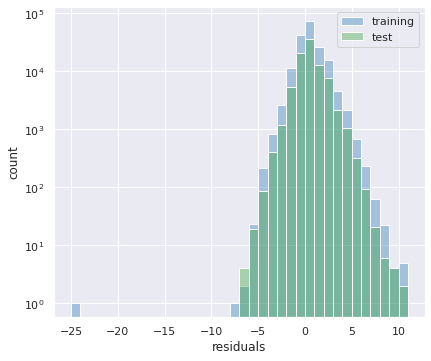

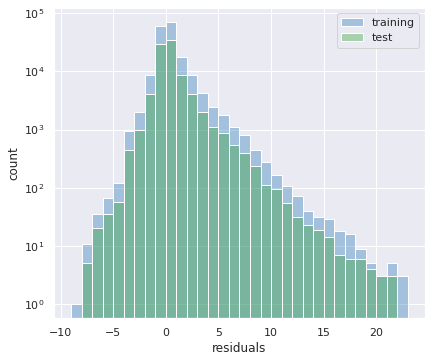

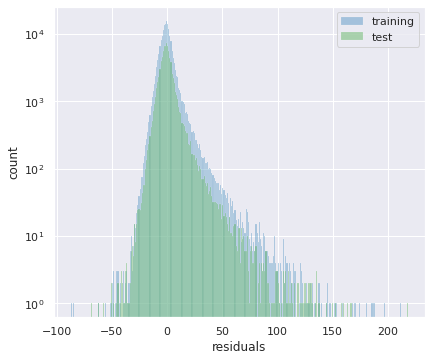

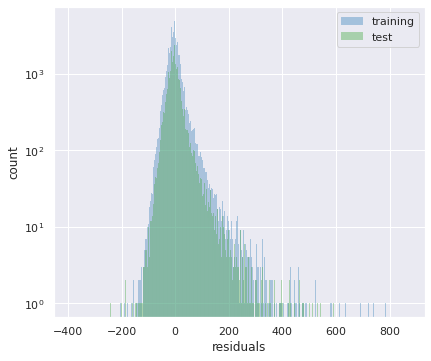

In [57]:
for lab, pred in predictions.items():
    pred.reshist(splits=['training', 'test'], logscale=(False, True), name='reshist_ols_' + lab, save=True, ctx=ctx)

We then take a look at the residual plots:

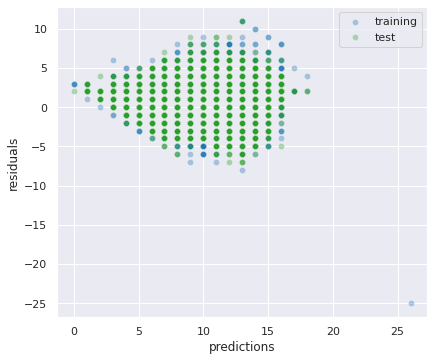

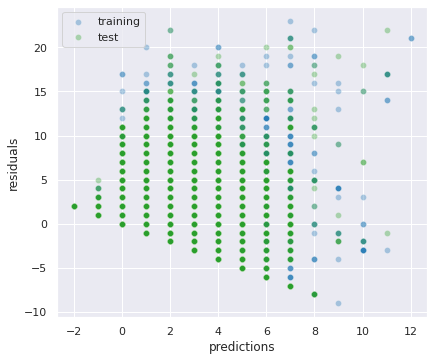

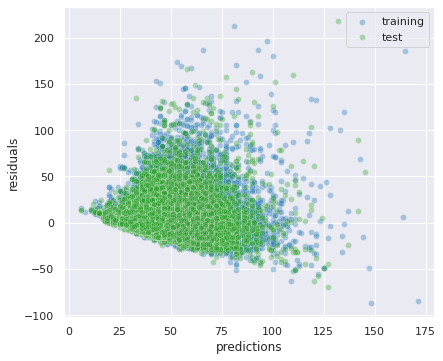

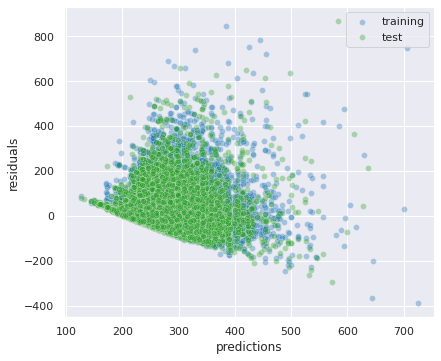

In [58]:
for lab, pred in predictions.items():
    pred.resplot(splits=['training', 'test'], name='resplot_ols_' + lab, save=True, ctx=ctx)

We finally compute the metrics:

In [61]:
for lab, pred in predictions.items():
    print(f'\nPredictions for {lab}:')
    pred.metrics(split='training', verbose=True, ctx=ctx)
    pred.metrics(split='test', verbose=True, ctx=ctx)


Predictions for h11:
TRAINING | accuracy = 0.408.
TEST | accuracy = 0.407.

Predictions for h21:
TRAINING | accuracy = 0.390.
TEST | accuracy = 0.389.

Predictions for h31:
TRAINING | accuracy = 0.077.
TEST | accuracy = 0.076.

Predictions for h22:
TRAINING | accuracy = 0.016.
TEST | accuracy = 0.016.


We save the predictions to file:

In [63]:
for lab, pred in predictions.items():
    pred.get_metrics(to_file=os.path.join(mod_dir, lab + '_metrics.json'));
    pred.get_predictions(to_file=os.path.join(mod_dir, lab + '_predictions.json'));
    pred.get_residuals(to_file=os.path.join(mod_dir, lab + '_residuals.json'));